## <span style=color:blue>DISCUSSION 6 - BENCHMARKING and VISUALIZATION Part 2</span>

In [1]:
import sys
import json
import csv
import yaml
import os

# can use the following as alternative way to load a large
#    set of environment variables; see below
from dotenv import load_dotenv

import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt


import time
from datetime import datetime

import pprint

import psycopg2
from sqlalchemy import create_engine, text as sql_text

import importlib

In [2]:
# Create an utilities file util.py in a folder helper_functions and import it
# In this example, I have the helper_functions directory in same parent
#    directory as where this jupyter notebook is

sys.path.append('ECS116-HELPER-FUNCTIONS/')
import util

# sanity check -- util.py has a small "hello_world" function in it
util.hello_world()

'hello world'

In [3]:
# Load the env file 
# Create a file '.env' in same parent directory as this jupyter notebook
# It should hold several environment variables; these will be loaded into
#     this notebook by the load_dotenv() function, and then used. (This may 
#     be easier than assigning them as universal environment variables, 
#     e.g., in .zshrc on a Mac. Also, this let's you use different environment 
#     variables in different notebooks and directories)

# Import the env variables

success = load_dotenv()

if success:
    print('Importing of environment variables appears to have been successful')
else:
    print('Importing of environment variables appears to have failed')

Importing of environment variables appears to have been successful


In [4]:
port = os.environ.get('pa2_port')          # for me, '5432'
host = os.getenv('pa2_host')               # for me, 'localhost'
database = os.getenv('pa2_db')             # for me, 'airbnb'
schema = os.getenv('pa2_schema')           # for me, 'new_york_city'
db_username = os.getenv('db_username')     # for me, 'postgres'
db_password = os.getenv('db_password')     # my password for postgres

print(port, host, database, schema, db_username)

5432 localhost airbnb new_york_city postgres


In [5]:
# Create the db engine 

db_eng = create_engine(f"postgresql+psycopg2://{db_username}:{db_password}@{host}:{port}/{database}",
                       connect_args={'options': '-csearch_path={}'.format(schema)},
                       isolation_level = 'SERIALIZABLE')

print("It appears that we have successfully created the db engine; need to run a query to be sure")

It appears that we have successfully created the db engine; need to run a query to be sure


In [6]:
# Checking connection to database by invoking a query 
# In this case, using a query that will fetch count
#   of records in reviews by year 

# Which year has the most reviews? Which year has the least reviews?

q = """
select left(to_char(date, 'YYYY-MM-DD'),4) as year, count(*)
from reviews
group by year
order by year"""

with db_eng.connect() as conn:
    result = conn.execute(sql_text(q))

result_list = result.fetchall()

pprint.pp(result_list)

[('2009', 50),
 ('2010', 441),
 ('2011', 1713),
 ('2012', 3476),
 ('2013', 6507),
 ('2014', 12377),
 ('2015', 25146),
 ('2016', 42974),
 ('2017', 59971),
 ('2018', 85871),
 ('2019', 111981),
 ('2020', 43306),
 ('2021', 89142),
 ('2022', 153621),
 ('2023', 175776),
 ('2024', 140315),
 ('2025', 18252)]


In [7]:
# reloading util in case you have modified it since previous run
importlib.reload(util)


# Create a function in util.py  to build a paramterized function
#    the produces a query that joins listings and reviews by listing ids,
#    and focuses on reviews from a single year
# We are testing the function here

# In this query we included an "ORDER BY" clause, just to make
#    the query take a little longer to run

date_start = '2015-01-01'
date_end = '2015-12-31'

q = util.build_query_listings_join_reviews(date_start, date_end)

print(q)


SELECT DISTINCT l.id, l.name
FROM listings l, reviews r 
WHERE l.id = r.listing_id
  AND r.datetime >= '2015-01-01'
  AND r.datetime <= '2015-12-31'
ORDER BY l.id;



In [8]:
# Checking the function build_query_listings_join_reviews on all years
# Note that when doing a pprint on strings in a dictionary, it
#    explicitly shows the next-line characters

importlib.reload(util)

q_dict = {}

for yr in range(2009,2026):
    q_name = 'listings_join_review_' + str(yr)
    date_start = str(yr) + '-01-01'
    date_end = str(yr) + '-12-31'
    q_dict[q_name] = util.build_query_listings_join_reviews(date_start, date_end)
    
pprint.pp(q_dict)


{'listings_join_review_2009': '\n'
                              'SELECT DISTINCT l.id, l.name\n'
                              'FROM listings l, reviews r \n'
                              'WHERE l.id = r.listing_id\n'
                              "  AND r.datetime >= '2009-01-01'\n"
                              "  AND r.datetime <= '2009-12-31'\n"
                              'ORDER BY l.id;\n',
 'listings_join_review_2010': '\n'
                              'SELECT DISTINCT l.id, l.name\n'
                              'FROM listings l, reviews r \n'
                              'WHERE l.id = r.listing_id\n'
                              "  AND r.datetime >= '2010-01-01'\n"
                              "  AND r.datetime <= '2010-12-31'\n"
                              'ORDER BY l.id;\n',
 'listings_join_review_2011': '\n'
                              'SELECT DISTINCT l.id, l.name\n'
                              'FROM listings l, reviews r \n'
                              'W

In [9]:
# Here is code to calculate the performance of a single query from q_dict
# You should probably create a function in your util.py that executes this
#     code (paramaterized by year), so that it is easy to call

# NOTE: before running this, you should add a timestamp column to
#    your table reviews, as per the instructions for PA2, Step 3a

# using a small count here, so that testing will run quickly
count = 3

time_list = []
for i in range(0,count):
    time_start = datetime.now()
    # Open new db connection for each execution of the query to avoid multithreading
    with db_eng.connect() as conn:
        df = pd.read_sql(q_dict['listings_join_review_2015'], con=conn)

    time_end = datetime.now()
    diff = util.time_diff(time_start, time_end)
    time_list.append(diff)

pprint.pp(time_list)
print('mean', round(sum(time_list)/len(time_list), 4), 'min', \
        round(min(time_list), 4), 'max', \
        round(max(time_list), 4), 'std', \
        round(np.std(time_list), 4))

[0.103259, 0.092005, 0.089146]
mean 0.0948 min 0.0891 max 0.1033 std 0.0061


<span style=color:blue>Why is there so much variation in the run times for different executions?  What happens to the standard deviation if you run the query 50 times rather than 3 times?</span>

In [10]:
# Adding and dropping indexes in the table reviews 

# Note: you may want to create helper functions in util.py for index creation/deletion,
#    rather than having them explicitly defined in your notebooks

q_create_date_in_reviews = '''
BEGIN TRANSACTION;
CREATE INDEX IF NOT EXISTS date_in_reviews
ON reviews(date);
END TRANSACTION;
'''

q_drop_date_in_reviews = '''
BEGIN TRANSACTION;
DROP INDEX IF EXISTS date_in_reviews;
END TRANSACTION;
'''

q_show_indexes_for_reviews = '''
select *
from pg_indexes
where tablename = 'reviews';
'''

# adding index date_in_reviews and then fetching all indexes from reviews
with db_eng.connect() as conn:
    conn.execute(sql_text(q_create_date_in_reviews))
    indexes_on_reviews = conn.execute(sql_text(q_show_indexes_for_reviews))
    
print('The set of indexes on reviews is: ')
print(indexes_on_reviews.all())

The set of indexes on reviews is: 
[('new_york_city', 'reviews', 'date_in_reviews', None, 'CREATE INDEX date_in_reviews ON new_york_city.reviews USING btree (date)')]


In [11]:
# Calculate statistics for each year

# Initialize the count to 20, so that things will run fairly quickly
count = 20

perf_details = {}

# Iterate through all the queries in q_dict (which was computed a few cells above here)
for year, sql_query in q_dict.items():
    time_list = []
    for i in range(count): 
        time_start = datetime.now()

        with db_eng.connect() as conn:
            df = pd.read_sql(sql_query, con=conn)

        time_end = datetime.now()
        # Calulate the time difference
        diff = util.time_diff(time_start, time_end)
        time_list.append(diff)

    # Splitting the string to get the year
    parts = year.split('_')
    curr_year = parts[-1]

    # Calulcate the metrics
    perf_profile = {
        'avg': round(sum(time_list) / len(time_list), 4),
        'min': round(min(time_list), 4),
        'max': round(max(time_list), 4),
        'std': round(np.std(time_list), 4)
        # remember to add count and timestamp in your outputs
    }

    # Add metrics according to the year
    perf_details[curr_year] = perf_profile

pprint.pp(perf_details)
    

{'2009': {'avg': 0.078, 'min': 0.0748, 'max': 0.1118, 'std': 0.0079},
 '2010': {'avg': 0.0763, 'min': 0.0751, 'max': 0.0777, 'std': 0.0007},
 '2011': {'avg': 0.0767, 'min': 0.0757, 'max': 0.0779, 'std': 0.0007},
 '2012': {'avg': 0.0772, 'min': 0.0766, 'max': 0.0786, 'std': 0.0006},
 '2013': {'avg': 0.0783, 'min': 0.0773, 'max': 0.0793, 'std': 0.0005},
 '2014': {'avg': 0.0849, 'min': 0.0802, 'max': 0.1361, 'std': 0.0119},
 '2015': {'avg': 0.0879, 'min': 0.084, 'max': 0.0904, 'std': 0.0016},
 '2016': {'avg': 0.0952, 'min': 0.093, 'max': 0.098, 'std': 0.0012},
 '2017': {'avg': 0.1065, 'min': 0.0986, 'max': 0.1806, 'std': 0.0174},
 '2018': {'avg': 0.1032, 'min': 0.0948, 'max': 0.1493, 'std': 0.0143},
 '2019': {'avg': 0.11, 'min': 0.096, 'max': 0.1482, 'std': 0.0147},
 '2020': {'avg': 0.0999, 'min': 0.0956, 'max': 0.1409, 'std': 0.0096},
 '2021': {'avg': 0.1021, 'min': 0.0917, 'max': 0.1473, 'std': 0.0106},
 '2022': {'avg': 0.1247, 'min': 0.1042, 'max': 0.2301, 'std': 0.0299},
 '2023': {'av

<span style=color:blue>Why do some years take longer than other years?</span>

In [12]:
# Create a seperate function for the above and put it in the util file.
# Run it again to be sure  

# NOTE: your function includes calls to "datetime.now()"
#    and so you need to include the lines
#          import time
#          from datetime import datetime
#    into your util.py file (best to put all imports at the top)
# and similarly for pandas (pd) and numpy (np)


# NOTE: your numbers may be slightly different - why?

importlib.reload(util)

count = 20

perf_details = {}

# remember: q_dict was computed a few cells above
perf_details = util.calc_time_diff_per_year(db_eng, count, q_dict)

pp = pprint.PrettyPrinter(indent=4)

pp.pprint(perf_details)

{   '2009': {'avg': 0.0757, 'max': 0.0838, 'min': 0.0739, 'std': 0.0025},
    '2010': {'avg': 0.0775, 'max': 0.0868, 'min': 0.0749, 'std': 0.0032},
    '2011': {'avg': 0.0755, 'max': 0.0783, 'min': 0.0748, 'std': 0.0008},
    '2012': {'avg': 0.0767, 'max': 0.0794, 'min': 0.0755, 'std': 0.0008},
    '2013': {'avg': 0.0774, 'max': 0.0787, 'min': 0.0767, 'std': 0.0006},
    '2014': {'avg': 0.081, 'max': 0.0819, 'min': 0.0784, 'std': 0.0008},
    '2015': {'avg': 0.0877, 'max': 0.089, 'min': 0.0847, 'std': 0.0009},
    '2016': {'avg': 0.0945, 'max': 0.0966, 'min': 0.093, 'std': 0.0008},
    '2017': {'avg': 0.1016, 'max': 0.1426, 'min': 0.0947, 'std': 0.0096},
    '2018': {'avg': 0.0996, 'max': 0.1403, 'min': 0.0956, 'std': 0.0094},
    '2019': {'avg': 0.1058, 'max': 0.1441, 'min': 0.0954, 'std': 0.0126},
    '2020': {'avg': 0.1006, 'max': 0.1406, 'min': 0.0958, 'std': 0.0094},
    '2021': {'avg': 0.1025, 'max': 0.1476, 'min': 0.0936, 'std': 0.0108},
    '2022': {'avg': 0.1173, 'max': 0.1549

In [13]:
# We need a way to save this data somewhere....let's save it in
# a separate output data directory and a file named example_perf_data.json

importlib.reload(util)

OUTPUT_DIR = '/Users/rick/DM-for-DS-2025/PA2-OUTPUT-DATA/'
perf_file = 'example_perf_data.json'
full_perf_file = OUTPUT_DIR + perf_file

# pattern that will test presence of perf, used here to avoid accidentally overwriting something
try:
    existing_perf_summary = util.fetch_perf_data(full_perf_file)
    print(f"Found data at {full_perf_file}, and fetched it into variable existing_perf_data")
    existing_perf_data = util.fetch_perf_data(full_file_name)
except:
    print(f"Did not find {full_perf_file}, \nso populating existing_perf_data with empty dictionary")
    existing_perf_data = {}

# adding new performance data to existing_perf_data
existing_perf_data['with_index'] = perf_details

# write updated perf_data out to full_perf_file
util.write_perf_data(existing_perf_data, full_perf_file)

print(f"Wrote file {full_perf_file}")

Did not find /Users/rick/DM-for-DS-2025/PA2-OUTPUT-DATA/example_perf_data.json, 
so populating existing_perf_data with empty dictionary
Wrote file /Users/rick/DM-for-DS-2025/PA2-OUTPUT-DATA/example_perf_data.json


In [14]:
# Drop the index on date in reviews

with db_eng.connect() as conn:
    conn.execute(sql_text(q_drop_date_in_reviews))

# Verify that the index was dropped
with db_eng.connect() as conn:
    conn.execute(sql_text(q_drop_date_in_reviews))
    indexes_on_reviews = conn.execute(sql_text(q_show_indexes_for_reviews))
    
print('The set of indexes on reviews is: ')
print(indexes_on_reviews.all())


The set of indexes on reviews is: 
[]


In [15]:
# Calculate the same metrics for review without the index

perf_details = util.calc_time_diff_per_year(db_eng, count, q_dict)

pp.pprint(perf_details)

{   '2009': {'avg': 0.077, 'max': 0.1087, 'min': 0.0744, 'std': 0.0073},
    '2010': {'avg': 0.0749, 'max': 0.0759, 'min': 0.0744, 'std': 0.0004},
    '2011': {'avg': 0.0753, 'max': 0.0766, 'min': 0.0744, 'std': 0.0005},
    '2012': {'avg': 0.0761, 'max': 0.0777, 'min': 0.0755, 'std': 0.0006},
    '2013': {'avg': 0.0771, 'max': 0.0779, 'min': 0.0765, 'std': 0.0004},
    '2014': {'avg': 0.0811, 'max': 0.0817, 'min': 0.0804, 'std': 0.0003},
    '2015': {'avg': 0.0883, 'max': 0.0905, 'min': 0.0856, 'std': 0.0012},
    '2016': {'avg': 0.0989, 'max': 0.1448, 'min': 0.0909, 'std': 0.0108},
    '2017': {'avg': 0.1069, 'max': 0.1512, 'min': 0.0974, 'std': 0.0135},
    '2018': {'avg': 0.1034, 'max': 0.1452, 'min': 0.0956, 'std': 0.0133},
    '2019': {'avg': 0.1044, 'max': 0.1467, 'min': 0.0947, 'std': 0.0102},
    '2020': {'avg': 0.101, 'max': 0.1448, 'min': 0.0935, 'std': 0.0111},
    '2021': {'avg': 0.1027, 'max': 0.1453, 'min': 0.0963, 'std': 0.01},
    '2022': {'avg': 0.1198, 'max': 0.1565,

In [16]:
# We need a way to save this data somewhere....let's save it in
# a separate output data directory and a file named example_perf_data.json

importlib.reload(util)

# Fetching existing data from file so that we can add to it
try:
    existing_perf_summary = util.fetch_perf_data(full_perf_file)
    print(f"Found data at {full_perf_file}, and fetching it into variable existing_perf_data")
    existing_perf_data = util.fetch_perf_data(full_perf_file)
except:
    print(f"ERROR: Did not find {full_perf_file}")

# adding new performance data to existing_perf_data
existing_perf_data['without_index'] = perf_details

# write updated perf_data out to full_perf_file
util.write_perf_data(existing_perf_data, full_perf_file)

print(f"Wrote file {full_perf_file}")   

# With this we have completed the benchmarking test focused on using or not using a single index
#      on the date column of the reviews table


Found data at /Users/rick/DM-for-DS-2025/PA2-OUTPUT-DATA/example_perf_data.json, and fetching it into variable existing_perf_data
Wrote file /Users/rick/DM-for-DS-2025/PA2-OUTPUT-DATA/example_perf_data.json


<span style=color:blue>Examples of how to visualize the data using matplotlib     </span>

In [17]:
# Load JSON data from the file
with open(full_perf_file, 'r') as file:
    data = json.load(file)

# Printing the loaded file
print(json.dumps(data, indent=4, sort_keys=True))

{
    "with_index": {
        "2009": {
            "avg": 0.0757,
            "max": 0.0838,
            "min": 0.0739,
            "std": 0.0025
        },
        "2010": {
            "avg": 0.0775,
            "max": 0.0868,
            "min": 0.0749,
            "std": 0.0032
        },
        "2011": {
            "avg": 0.0755,
            "max": 0.0783,
            "min": 0.0748,
            "std": 0.0008
        },
        "2012": {
            "avg": 0.0767,
            "max": 0.0794,
            "min": 0.0755,
            "std": 0.0008
        },
        "2013": {
            "avg": 0.0774,
            "max": 0.0787,
            "min": 0.0767,
            "std": 0.0006
        },
        "2014": {
            "avg": 0.081,
            "max": 0.0819,
            "min": 0.0784,
            "std": 0.0008
        },
        "2015": {
            "avg": 0.0877,
            "max": 0.089,
            "min": 0.0847,
            "std": 0.0009
        },
        "2016": {
          

In [18]:
# Convert the json into dataframes

df_with_index = pd.DataFrame(data['with_index']).transpose()
df_without_index = pd.DataFrame(data['without_index']).transpose()

print(df_with_index)
print(df_without_index)

         avg     min     max     std
2009  0.0757  0.0739  0.0838  0.0025
2010  0.0775  0.0749  0.0868  0.0032
2011  0.0755  0.0748  0.0783  0.0008
2012  0.0767  0.0755  0.0794  0.0008
2013  0.0774  0.0767  0.0787  0.0006
2014  0.0810  0.0784  0.0819  0.0008
2015  0.0877  0.0847  0.0890  0.0009
2016  0.0945  0.0930  0.0966  0.0008
2017  0.1016  0.0947  0.1426  0.0096
2018  0.0996  0.0956  0.1403  0.0094
2019  0.1058  0.0954  0.1441  0.0126
2020  0.1006  0.0958  0.1406  0.0094
2021  0.1025  0.0936  0.1476  0.0108
2022  0.1173  0.1074  0.1549  0.0153
2023  0.1226  0.1108  0.1553  0.0136
2024  0.1187  0.1070  0.1571  0.0156
2025  0.0922  0.0871  0.1314  0.0093
         avg     min     max     std
2009  0.0770  0.0744  0.1087  0.0073
2010  0.0749  0.0744  0.0759  0.0004
2011  0.0753  0.0744  0.0766  0.0005
2012  0.0761  0.0755  0.0777  0.0006
2013  0.0771  0.0765  0.0779  0.0004
2014  0.0811  0.0804  0.0817  0.0003
2015  0.0883  0.0856  0.0905  0.0012
2016  0.0989  0.0909  0.1448  0.0108
2

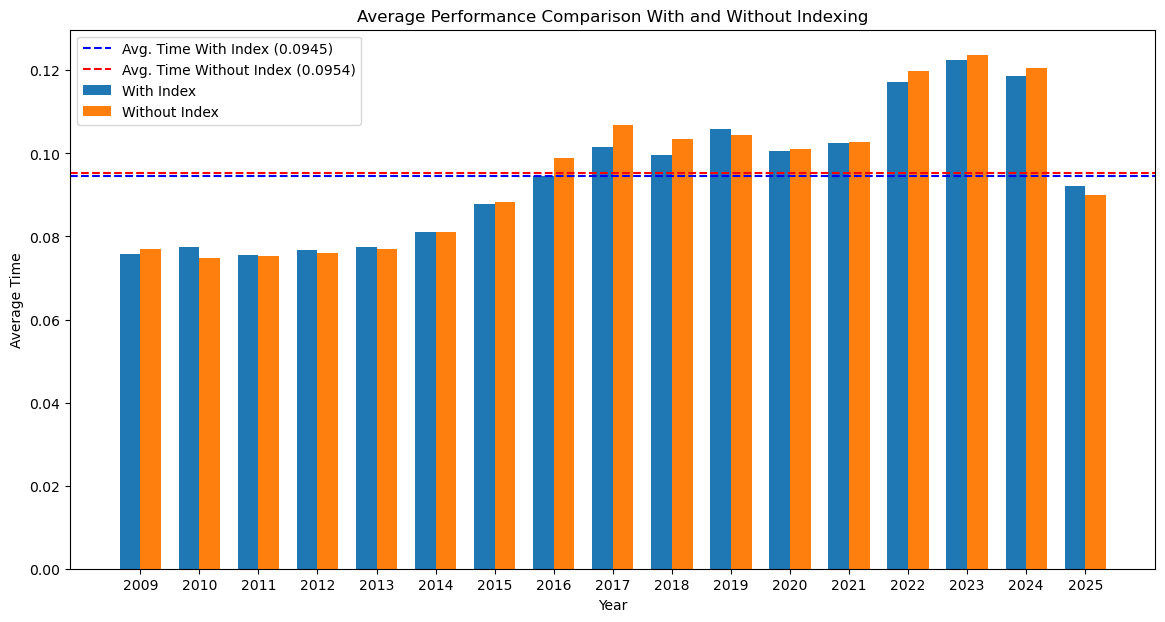

In [19]:
# Plot to compare the performances with and without indexes with respect to average time

plt.figure(figsize=(14, 7))
index = range(len(df_with_index))
bar_width = 0.35

plt.bar(index, df_with_index['avg'], bar_width, label='With Index')
plt.bar([p + bar_width for p in index], df_without_index['avg'], bar_width, label='Without Index')

# Calculate and plot the average times for with_bm and without_bm
avg_time_with_index = df_with_index['avg'].mean()
avg_time_without_index = df_without_index['avg'].mean()

plt.axhline(y=avg_time_with_index, color='blue', linestyle='--', label=f'Avg. Time With Index ({avg_time_with_index:.4f})')
plt.axhline(y=avg_time_without_index, color='red', linestyle='--', label=f'Avg. Time Without Index ({avg_time_without_index:.4f})')

plt.xlabel('Year')
plt.ylabel('Average Time')
plt.title('Average Performance Comparison With and Without Indexing')
plt.xticks([p + bar_width / 2 for p in index], df_with_index.index)
plt.legend()
plt.show()

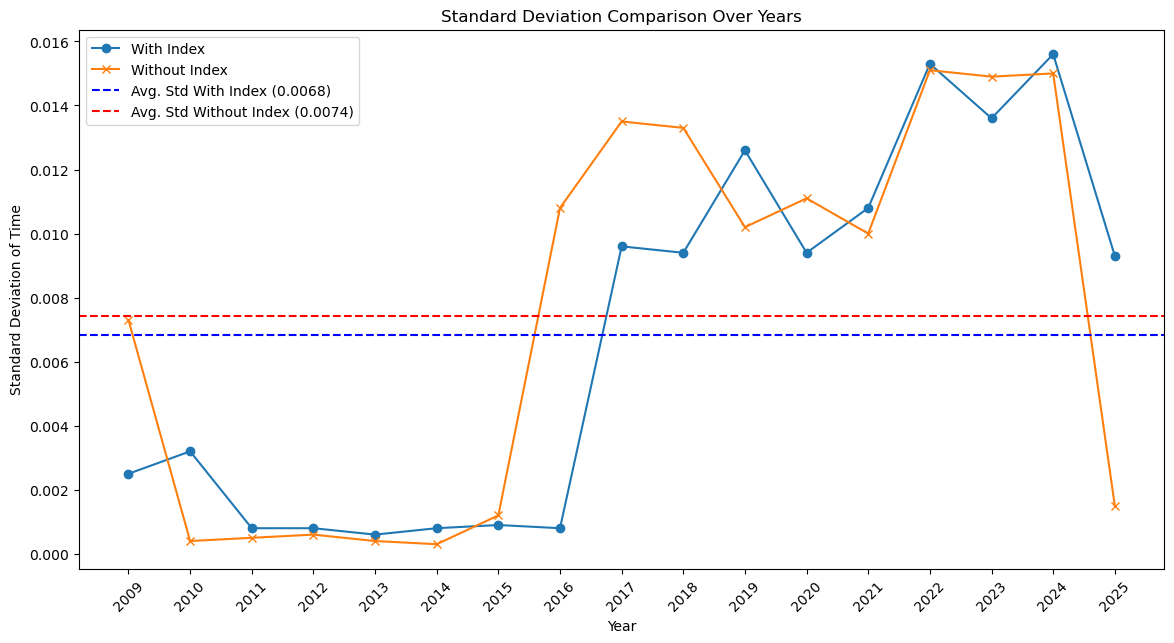

In [20]:
# Plot to compare the performances with and without indexes with respect to standard deviation

plt.figure(figsize=(14, 7))

# Plot standard deviations
plt.plot(df_with_index.index, df_with_index['std'], label='With Index', marker='o')
plt.plot(df_without_index.index, df_without_index['std'], label='Without Index', marker='x')

# Calculate and plot the average standard deviation for with_bm and without_bm
avg_std_with_index = df_with_index['std'].mean()
avg_std_without_index = df_without_index['std'].mean()

plt.axhline(y=avg_std_with_index, color='blue', linestyle='--', label=f'Avg. Std With Index ({avg_std_with_index:.4f})')
plt.axhline(y=avg_std_without_index, color='red', linestyle='--', label=f'Avg. Std Without Index ({avg_std_without_index:.4f})')

plt.xlabel('Year')
plt.ylabel('Standard Deviation of Time')
plt.title('Standard Deviation Comparison Over Years')
plt.xticks(rotation=45)
plt.legend()
plt.show()

## <span style=color:blue>Using Prog Assgmt 2 json files for Visualization</span>

In [21]:
# Using the json files from PA 2 ---- listings_join_reviews (You can find this in the Files section under PROG-ASSGMT-2)

# Load JSON data from a file




with open(OUTPUT_DIR + '2024_listings_join_reviews_on_mac_v03.json', 'r') as file:
    data_listings = json.load(file)

# Printing the loaded file
print(json.dumps(data_listings, indent=4, sort_keys=True))

{
    "listings_join_reviews_2009": {
        "__": {
            "avg": 0.3367,
            "count": 50,
            "max": 3.7037,
            "min": 0.242,
            "std": 0.4821,
            "timestamp": "2024-05-10-18:31:16"
        },
        "__datetime_in_reviews__": {
            "avg": 0.0143,
            "count": 50,
            "max": 0.0223,
            "min": 0.013,
            "std": 0.0014,
            "timestamp": "2024-05-10-18:31:18"
        },
        "__datetime_in_reviews__id_in_listings__": {
            "avg": 0.0144,
            "count": 50,
            "max": 0.0176,
            "min": 0.0132,
            "std": 0.0008,
            "timestamp": "2024-05-10-18:31:31"
        },
        "__id_in_listings__": {
            "avg": 0.2337,
            "count": 50,
            "max": 0.2685,
            "min": 0.219,
            "std": 0.0119,
            "timestamp": "2024-05-10-18:31:30"
        }
    },
    "listings_join_reviews_2010": {
        "__": {
     

In [22]:
# Renaming the keys
importlib.reload(util)

# This next function rewrites the json file by dropping the prefix from strings such as 
#       "listings_join_reviews_2009" to create the string "2009"
data_listings_renamed = util.drop_prefixes_in_keys(data_listings)

pp.pprint(data_listings_renamed)

{   '2009': {   '__': {   'avg': 0.3367,
                          'count': 50,
                          'max': 3.7037,
                          'min': 0.242,
                          'std': 0.4821,
                          'timestamp': '2024-05-10-18:31:16'},
                '__datetime_in_reviews__': {   'avg': 0.0143,
                                               'count': 50,
                                               'max': 0.0223,
                                               'min': 0.013,
                                               'std': 0.0014,
                                               'timestamp': '2024-05-10-18:31:18'},
                '__datetime_in_reviews__id_in_listings__': {   'avg': 0.0144,
                                                               'count': 50,
                                                               'max': 0.0176,
                                                               'min': 0.0132,
                                  

In [23]:
# Extract the avg values for each key inside each year object
def extract_avg_values(data):
    avg_values = {}
    for year, details in data.items():
        avg_values[year] = {}
        for key, metrics in details.items():
            if 'avg' in metrics:
                avg_values[year][key] = metrics['avg']
    return avg_values

# Extract the avg values
avg_values = extract_avg_values(data_listings_renamed)

pp.pprint(avg_values)

# Map the keys to the custom labels
key_labels = {
    "__": "no_index",
    "__datetime_in_reviews__": "datetime_index",
    "__id_in_listings__": "id_index",
    "__datetime_in_reviews__id_in_listings__": "datetime_and_id_index"
}

# Prepare data for DataFrame
data_for_df = {label: [] for label in key_labels.values()}
data_for_df['Year'] = sorted(avg_values.keys())

for year in data_for_df['Year']:
    for key, label in key_labels.items():
        data_for_df[label].append(avg_values[year].get(key, None))

# Create DataFrame
df = pd.DataFrame(data_for_df)

# Set 'Year' as the index
df.set_index('Year', inplace=True)

# Display the DataFrame
print(df)

{   '2009': {   '__': 0.3367,
                '__datetime_in_reviews__': 0.0143,
                '__datetime_in_reviews__id_in_listings__': 0.0144,
                '__id_in_listings__': 0.2337},
    '2010': {   '__': 0.2415,
                '__datetime_in_reviews__': 0.0163,
                '__datetime_in_reviews__id_in_listings__': 0.0154,
                '__id_in_listings__': 0.2368},
    '2011': {   '__': 0.2488,
                '__datetime_in_reviews__': 0.0168,
                '__datetime_in_reviews__id_in_listings__': 0.0169,
                '__id_in_listings__': 0.2442},
    '2012': {   '__': 0.2493,
                '__datetime_in_reviews__': 0.02,
                '__datetime_in_reviews__id_in_listings__': 0.0193,
                '__id_in_listings__': 0.248},
    '2013': {   '__': 0.2447,
                '__datetime_in_reviews__': 0.0238,
                '__datetime_in_reviews__id_in_listings__': 0.0246,
                '__id_in_listings__': 0.2546},
    '2014': {   '__': 0.2651

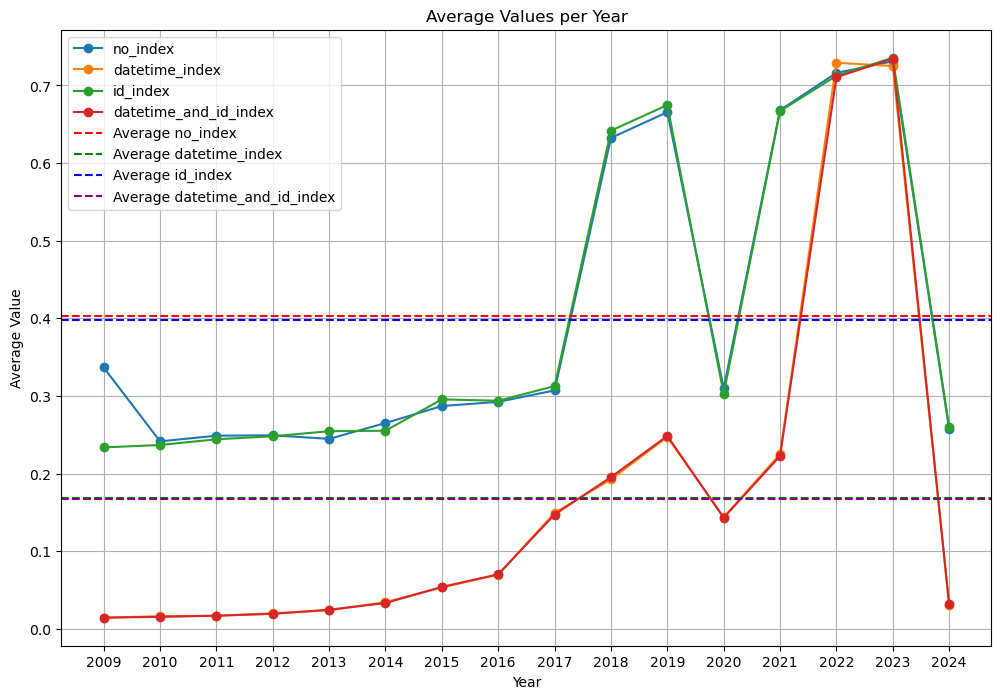

In [24]:
# Plotting the data
plt.figure(figsize=(12, 8))

# Plot each category data
for label in key_labels.values():
    plt.plot(df.index, df[label], marker='o', label=label)
    
colors = ['red', 'green', 'blue', 'purple']

# Calculate and plot average lines for each index across all years
for idx, label in enumerate(key_labels.values()):
    avg_value = df[label].mean()
    plt.axhline(y=avg_value, linestyle='--', color=colors[idx], label=f'Average {label}')

plt.title('Average Values per Year')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.legend()
plt.grid(True)
plt.show()